In [28]:
import ollama 
import os
from tqdm import tqdm
import json
import signal
import argparse
import wandb
import pandas as pd
import matplotlib.pyplot as plt

import sys
from collections import defaultdict

#from  utilities import *

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
sys.argv = [
    'notebook',  
    '--modelname', 'llava:7b',
    '--data', 'gully',
    '--data_path','/home/data/',
    "--data_samples", 'train.jsonl',
    "--subset", 'train',
    '--results_dir', '/home/WACV-2025-Workshop-ViGIR/results/baseline',
    '--timeout', '20',
    '--model_unloading'
]

In [4]:
parser = argparse.ArgumentParser(description="A script to run V-LLMs on different image classification datasets")

In [5]:
# set up the argument parser
parser.add_argument("--modelname", type=str, required=True, help="The name of the V-LLM model")
parser.add_argument("--data", type=str, required=True, help="Dataset name")
parser.add_argument("--data_path", type=str, required=True, help="Path to the image data dir")
parser.add_argument("--data_samples", type=str, required=True, help="Name of the samples to run on")
parser.add_argument("--subset", type=str, required=True, help="train, test or validation set")
parser.add_argument("--results_dir", type=str, required=True, help="Folder name to save results")
parser.add_argument("--timeout", type=int, default=40, help="time out duration to skip one sample")
parser.add_argument("--model_unloading", action="store_true", help="Enables unloading mode. Every 100 sampels it unloades the model from the GPU to avoid carshing.")


args = parser.parse_args()

In [6]:
# Set up the wandb run 
run = wandb.init(
    entity="jacketdembys",
    project=f"wacv-2025-{args.data}",
    name="run_test_" + args.data+"-"+args.modelname+"-"+args.subset
)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

  ········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [7]:
# Load the images
directory = '/root/home/data_jpg'
tile_dict = defaultdict(list)

for filename in os.listdir(directory):
    if filename.endswith('.jpg'):
        parts = filename.split('_')
        tile_number = parts[4].split('.')[0]
        tile_dict[tile_number].append(os.path.join(directory,filename))

tile_dict = dict(tile_dict)

print("Total number of tiles: {}".format(len(tile_dict.keys())))

Total number of tiles: 900


In [8]:
for tile_number, file_list in tile_dict.items():
    tile_dict[tile_number] = sorted(file_list, key=lambda x: int(x.split('_')[3]))


In [12]:
unwanted_patterns = ['rgb_0', 'rgb_2', 'rgb_4']

In [13]:
data = {key: [path for path in paths if not any(sub in path for sub in unwanted_patterns)] 
        for key, paths in tile_dict.items()}

In [14]:
data

{'100': ['/root/home/data_jpg/neg_rgb_1_tile_100.jpg',
  '/root/home/data_jpg/neg_rgb_3_tile_100.jpg',
  '/root/home/data_jpg/neg_rgb_5_tile_100.jpg'],
 '1000': ['/root/home/data_jpg/neg_rgb_1_tile_1000.jpg',
  '/root/home/data_jpg/neg_rgb_3_tile_1000.jpg',
  '/root/home/data_jpg/neg_rgb_5_tile_1000.jpg'],
 '1001': ['/root/home/data_jpg/neg_rgb_1_tile_1001.jpg',
  '/root/home/data_jpg/neg_rgb_3_tile_1001.jpg',
  '/root/home/data_jpg/neg_rgb_5_tile_1001.jpg'],
 '1002': ['/root/home/data_jpg/neg_rgb_1_tile_1002.jpg',
  '/root/home/data_jpg/neg_rgb_3_tile_1002.jpg',
  '/root/home/data_jpg/neg_rgb_5_tile_1002.jpg'],
 '1003': ['/root/home/data_jpg/neg_rgb_1_tile_1003.jpg',
  '/root/home/data_jpg/neg_rgb_3_tile_1003.jpg',
  '/root/home/data_jpg/neg_rgb_5_tile_1003.jpg'],
 '1004': ['/root/home/data_jpg/neg_rgb_1_tile_1004.jpg',
  '/root/home/data_jpg/neg_rgb_3_tile_1004.jpg',
  '/root/home/data_jpg/neg_rgb_5_tile_1004.jpg'],
 '1005': ['/root/home/data_jpg/neg_rgb_1_tile_1005.jpg',
  '/root/ho

In [25]:
"""
questions = [
    "Across the images, do you see a low point in the terrain where a temporary gully or depression begins to form without a permanent water feature? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do narrow, winding paths or channels appear and become more defined across the sequence? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Over time, do any linear depressions or ruts become more pronounced along natural drainage lines or slopes? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Does a narrow, shallow channel become visibly deeper or more indented into the soil over the image sequence? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Are there areas where soil appears disturbed or vegetation is removed, showing progression over the images? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Across the sequence, does a specific path lack vegetation, suggesting an evolving or emerging channel? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Does the texture of the soil appear to change, becoming coarser or showing small pebbles in areas that develop into channels? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Can you see any clear starting and ending points for these channels becoming more evident over time? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do small rills or grooves indicating water flow appear or deepen across the images? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Is there a gradual exposure of lighter-colored soil as the gully forms? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Are there sediment accumulations forming at the lower ends of channels as time progresses? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Across the images, do signs of water activity, like soil clumps or crusting, appear or intensify in specific areas? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do shallow side walls along the channel areas become more defined as the sequence progresses? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do deposits of silt or small debris appear and accumulate along any emerging channel paths? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Can you observe branching patterns that resemble temporary streams forming or intensifying over time? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do areas with compacted soil or minor slope collapse become more noticeable along the developing channel edges? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Are there indications of nearby human activity, such as tillage or machinery tracks, influencing the formation or expansion of these channels? Please answer with YES or NO Only. DO NOT mention the reason."
]
"""

questions = ["How many images do you see?"]

In [26]:
model_name = args.modelname
ollama.pull(model_name)

timeout_duration = args.timeout

options= {  # new
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048, # must be set, otherwise slightly random output
        }

model_labels = {}
count = 0

In [27]:
count = 0
saving_response=dict(tile_dict)

for key,info in tqdm(data.items()):

    count+=1
    for question in questions:
        response = ollama.generate(model=model_name, 
                                   prompt=question, 
                                   images=info, 
                                   options=options)
        saving_response[key].append(response['response'])
        print(response['response'])

        sys.exit()
        
       
    

  0%|                                                                                                              | 0/900 [00:03<?, ?it/s]

 There is only one image visible in the provided link. It shows an aerial view of a forested area with dense tree coverage. 


SystemExit: 0

In [24]:
print(info)
image_file = info[0]
print()
print(image_file)
img = Image.open(image_file)

['/root/home/data_jpg/neg_rgb_1_tile_100.jpg', '/root/home/data_jpg/neg_rgb_3_tile_100.jpg', '/root/home/data_jpg/neg_rgb_5_tile_100.jpg']

/root/home/data_jpg/neg_rgb_1_tile_100.jpg


In [22]:
pwd

'/root/home/WACV-2025-Workshop-ViGIR'

NameError: name 'path' is not defined

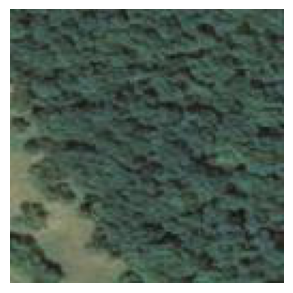

In [30]:
# Read and display the images
images = [Image.open(path) for path in info]

# Plot the images using Matplotlib
plt.figure(figsize=(12, 8))
#for i, img in enumerate(images):
for i, (img, path) in enumerate(zip(images, image_paths)):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns
    plt.imshow(img)
    plt.axis('off')  # Turn off axis
    plt.title(os.path.basename(path))
plt.tight_layout()
plt.show()
